# 实验4：卷积神经网络及应用实验

这份 notebook 按实验三的形式拆成多个步骤，方便你一个单元格一个单元格运行、截图和写报告。

整个流程可以分成下面 9 步：

1. 导入库，并设置实验环境。
2. 加载 Fashion-MNIST 数据集，并自动寻找本地数据路径。
3. 展示样本图片和类别分布。
4. 构建两层卷积、两层池化、两层全连接的 CNN。
5. 定义训练和测试函数。
6. 训练 10 轮并记录 loss、训练准确率、测试准确率。
7. 绘制损失曲线、准确率曲线和每轮耗时。
8. 评估测试集，绘制混淆矩阵、每类准确率和 8 张预测结果图。
9. 做一个卷积通道数的超参数影响分析。


## 第 1 步：导入库并设置实验环境

这一部分先把实验需要的库、随机种子、超参数和图片保存函数准备好。

本实验的主要设置是：

- 数据集：Fashion-MNIST
- 损失函数：`CrossEntropyLoss`
- 优化器：`Adam`
- 学习率：`0.001`
- batch size：`64`
- 训练轮数：`10`
- `num_workers=0`，避免 Windows 下 DataLoader 多进程问题


In [2]:
# 忽略一些不影响实验结论的警告，避免输出太乱
import warnings
warnings.filterwarnings("ignore")

# 标准库
import random
import time
from pathlib import Path
from typing import Dict, List, Optional, Sequence, Tuple

# 数据分析和画图
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# notebook 中表格显示更整齐
from IPython.display import display

# PyTorch 相关库
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms

# 设置默认绘图风格
sns.set_theme(style="whitegrid")

# 设置中文字体，防止标题和图例乱码
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
plt.rcParams["axes.unicode_minus"] = False

# 实验超参数
RANDOM_SEED = 42
BATCH_SIZE = 64
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
NUM_WORKERS = 0

# 超参数对比设置。若电脑运行较慢，可以只跳过最后一个单元格，或把这里改成 False。
RUN_HYPERPARAMETER_COMPARISON = True
HYPERPARAM_EPOCHS = 5
HYPERPARAM_TRAIN_LIMIT = 15000

# 实验四目录。这样即使 notebook 的工作目录变化，也能把图片保存到实验四文件夹。
EXPERIMENT4_DIR = Path(r"C:\Users\qintian\Desktop\人工智能\实验四")
EXPERIMENT3_DATA_DIR = EXPERIMENT4_DIR.parent / "实验三_发送版" / "fashion_mnist"

# Fashion-MNIST 一共 10 个类别
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]


def set_seed(seed: int = RANDOM_SEED) -> None:
    """
    固定随机种子，尽量让实验结果稳定。
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def get_device() -> torch.device:
    """
    自动选择运行设备：优先使用 GPU，没有 GPU 时使用 CPU。
    """
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def save_plot(filename: str) -> None:
    """
    保存图像到实验四目录，同时在 notebook 中显示图像。
    """
    output_path = EXPERIMENT4_DIR / filename
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(f"图像已保存：{filename}")
    plt.show()
    plt.close()


def denormalize_image(image: torch.Tensor) -> torch.Tensor:
    """
    把 Normalize((0.5,), (0.5,)) 后的图像还原到 [0, 1]，便于显示。
    """
    return image * 0.5 + 0.5


## 第 2 步：加载数据并认识 Fashion-MNIST

Fashion-MNIST 是一个服饰图像分类数据集，可以把它看成“衣服版 MNIST”。

它有下面这些特点：

- 每张图片大小都是 `28 x 28`
- 图片是灰度图，所以通道数为 `1`
- 一共有 `10` 个类别
- 训练集有 `60000` 张图片
- 测试集有 `10000` 张图片

这里的数据路径会按下面顺序自动寻找：

1. 实验四目录下的 `fashion_mnist`
2. 实验三目录下的 `fashion_mnist`
3. 如果两个位置都找不到，就提示复制数据集或手动开启下载


In [3]:
def has_fashion_mnist_files(data_root: Path) -> bool:
    """
    判断指定目录下是否已经存在 torchvision 可读取的 Fashion-MNIST 文件。
    """
    raw_dir = data_root / "FashionMNIST" / "raw"
    required_files = [
        "train-images-idx3-ubyte",
        "train-labels-idx1-ubyte",
        "t10k-images-idx3-ubyte",
        "t10k-labels-idx1-ubyte",
    ]
    return raw_dir.exists() and all((raw_dir / name).exists() for name in required_files)


def resolve_data_root() -> Path:
    """
    优先使用实验四目录数据集，若不存在则回退到实验三数据集。
    """
    candidates = [
        EXPERIMENT4_DIR / "fashion_mnist",
        EXPERIMENT3_DATA_DIR,
    ]

    for data_root in candidates:
        if has_fashion_mnist_files(data_root):
            return data_root

    message = (
        "未找到 Fashion-MNIST 本地数据集。\n"
        f"已检查：\n1. {candidates[0]}\n2. {candidates[1]}\n"
        "请将实验三的 fashion_mnist 文件夹复制到实验四目录，"
        "或在确认可以联网后把 datasets.FashionMNIST 的 download=False 改成 download=True。"
    )
    raise FileNotFoundError(message)


def build_dataloaders(data_root: Path):
    """
    加载 Fashion-MNIST 训练集和测试集。

    参数：
    - data_root: 数据集所在根目录。

    返回值：
    - train_dataset: 训练集
    - test_dataset: 测试集
    - train_loader: 训练集 DataLoader
    - test_loader: 测试集 DataLoader
    """
    # ToTensor() 先把像素缩放到 [0, 1]，Normalize() 再映射到 [-1, 1]
    transform = transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ]
    )

    train_dataset = datasets.FashionMNIST(
        root=str(data_root),
        train=True,
        transform=transform,
        download=False,
    )
    test_dataset = datasets.FashionMNIST(
        root=str(data_root),
        train=False,
        transform=transform,
        download=False,
    )

    loader_kwargs = {
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "pin_memory": torch.cuda.is_available(),
    }

    train_loader = DataLoader(train_dataset, shuffle=True, **loader_kwargs)
    test_loader = DataLoader(test_dataset, shuffle=False, **loader_kwargs)

    return train_dataset, test_dataset, train_loader, test_loader


set_seed(RANDOM_SEED)
device = get_device()
data_root = resolve_data_root()
train_dataset, test_dataset, train_loader, test_loader = build_dataloaders(data_root)

print("当前设备：", device)
print("数据目录：", data_root)
print(f"训练集样本数：{len(train_dataset)}")
print(f"测试集样本数：{len(test_dataset)}")
print(f"训练集批次数：{len(train_loader)}")
print(f"测试集批次数：{len(test_loader)}")
print(f"batch size：{BATCH_SIZE}")
print(f"epochs：{NUM_EPOCHS}")
print(f"学习率：{LEARNING_RATE}")

class_df = pd.DataFrame(
    {"类别编号": list(range(10)), "类别名称": CLASS_NAMES}
)
display(class_df)


当前设备： cuda
数据目录： C:\Users\qintian\Desktop\人工智能\实验三_发送版\fashion_mnist
训练集样本数：60000
测试集样本数：10000
训练集批次数：938
测试集批次数：157
batch size：64
epochs：10
学习率：0.001


,类别编号,类别名称
0,0,T-shirt/top
1,1,Trouser
2,2,Pullover
3,3,Dress
4,4,Coat
5,5,Sandal
6,6,Shirt
7,7,Sneaker
8,8,Bag
9,9,Ankle boot


## 第 3 步：展示样本图像和类别分布

这一部分用于直观认识数据集，也方便报告中“数据集准备”部分截图。

会保存两张图片：

- `exp4_sample_images.png`：若干 Fashion-MNIST 样本图像
- `exp4_class_distribution.png`：训练集和测试集各类别数量


图像已保存：exp4_sample_images.png


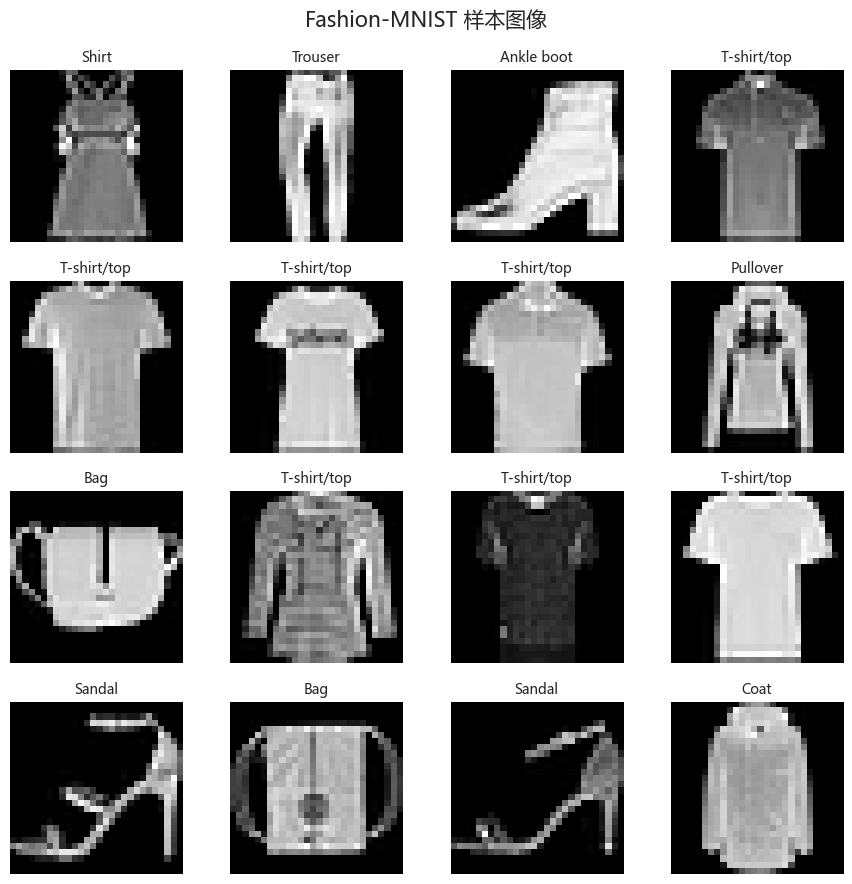

图像已保存：exp4_class_distribution.png


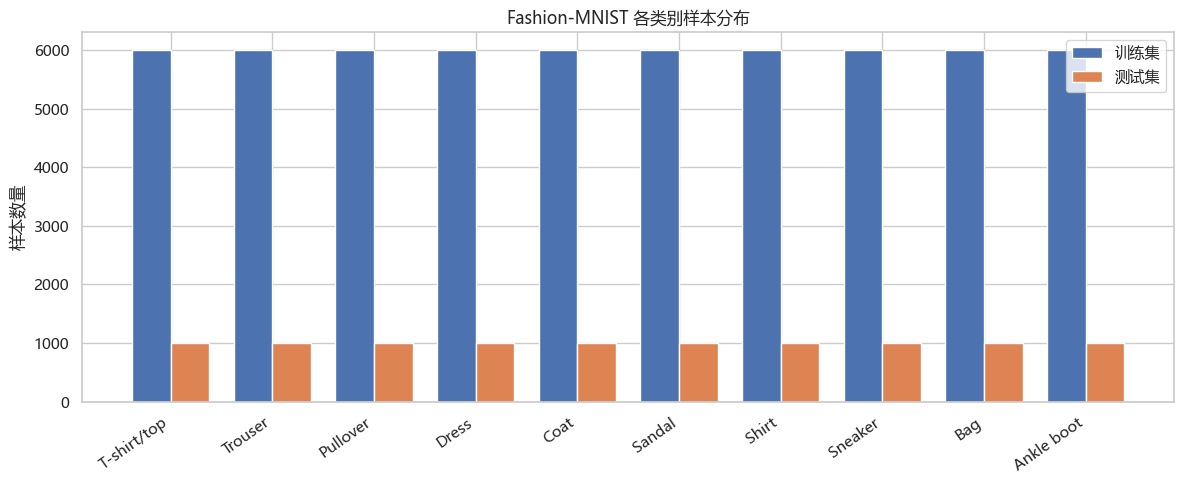

In [4]:
def get_targets(dataset: datasets.FashionMNIST) -> np.ndarray:
    """
    读取 Fashion-MNIST 标签，便于画类别分布。
    """
    return np.array(dataset.targets)


def plot_sample_images(dataset: datasets.FashionMNIST) -> None:
    """
    展示若干训练样本，直观看 Fashion-MNIST 的图像和类别。
    """
    rng = random.Random(RANDOM_SEED)
    indices = rng.sample(range(len(dataset)), 16)

    fig, axes = plt.subplots(4, 4, figsize=(9, 9))
    for ax, idx in zip(axes.flat, indices):
        image, label = dataset[idx]
        image = denormalize_image(image).squeeze(0)
        ax.imshow(image, cmap="gray")
        ax.set_title(CLASS_NAMES[label], fontsize=10)
        ax.axis("off")

    plt.suptitle("Fashion-MNIST 样本图像", fontsize=15)
    plt.tight_layout()
    save_plot("exp4_sample_images.png")


def plot_class_distribution(
    train_dataset: datasets.FashionMNIST,
    test_dataset: datasets.FashionMNIST,
) -> None:
    """
    绘制训练集和测试集的类别分布。
    """
    train_counts = np.bincount(get_targets(train_dataset), minlength=len(CLASS_NAMES))
    test_counts = np.bincount(get_targets(test_dataset), minlength=len(CLASS_NAMES))

    x = np.arange(len(CLASS_NAMES))
    width = 0.38
    plt.figure(figsize=(12, 5))
    plt.bar(x - width / 2, train_counts, width=width, label="训练集")
    plt.bar(x + width / 2, test_counts, width=width, label="测试集")
    plt.xticks(x, CLASS_NAMES, rotation=35, ha="right")
    plt.ylabel("样本数量")
    plt.title("Fashion-MNIST 各类别样本分布")
    plt.legend()
    plt.tight_layout()
    save_plot("exp4_class_distribution.png")


plot_sample_images(train_dataset)
plot_class_distribution(train_dataset, test_dataset)


## 第 4 步：构建 CNN 模型

题目要求的 CNN 结构是“两层卷积、两层池化、两层全连接”。

本实验使用的结构如下：

- `Conv2d(1, 32, kernel_size=3, padding=1)`
- `BatchNorm2d(32)`
- `ReLU`
- `MaxPool2d(2, 2)`，图像大小从 `28 x 28` 变成 `14 x 14`
- `Conv2d(32, 64, kernel_size=3, padding=1)`
- `BatchNorm2d(64)`
- `ReLU`
- `MaxPool2d(2, 2)`，图像大小从 `14 x 14` 变成 `7 x 7`
- `Flatten`
- `Linear(64 * 7 * 7, 128)`
- `ReLU`
- `Dropout(0.5)`
- `Linear(128, 10)`


In [5]:
class FashionCNN(nn.Module):
    """
    两层卷积、两层池化、两层全连接的基础 CNN。
    """

    def __init__(self, channels: Tuple[int, int] = (32, 64), num_classes: int = 10) -> None:
        super().__init__()
        c1, c2 = channels

        self.features = nn.Sequential(
            # 第一组卷积：输入 1x28x28，池化后变为 c1x14x14
            nn.Conv2d(1, c1, kernel_size=3, padding=1),
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # 第二组卷积：输入 c1x14x14，池化后变为 c2x7x7
            nn.Conv2d(c1, c2, kernel_size=3, padding=1),
            nn.BatchNorm2d(c2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(c2 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x


model = FashionCNN(channels=(32, 64)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print("模型结构：")
print(model)


模型结构：
FashionCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)


## 第 5 步：定义训练与测试函数

为了让主流程更清楚，把训练过程拆成两个函数：

- `run_one_epoch()`：跑一轮训练或测试
- `train_model()`：循环训练多轮，并记录每轮结果

`CrossEntropyLoss` 内部已经包含 softmax 的计算，所以模型最后一层直接输出 logits，不需要手动加 softmax。


In [6]:
def run_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    optimizer: Optional[torch.optim.Optimizer] = None,
) -> Tuple[float, float]:
    """
    执行一轮训练或测试，返回平均损失和准确率。
    """
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.set_grad_enabled(is_train):
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            batch_size = labels.size(0)
            total_loss += loss.item() * batch_size
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += batch_size

    return total_loss / total_samples, total_correct / total_samples


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    criterion: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    num_epochs: int,
    log_prefix: str = "",
) -> pd.DataFrame:
    """
    训练模型，并记录每个 epoch 的 loss、训练准确率、测试准确率和耗时。
    """
    history = []

    for epoch in range(1, num_epochs + 1):
        start_time = time.time()

        train_loss, train_acc = run_one_epoch(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            optimizer=optimizer,
            device=device,
        )
        test_loss, test_acc = run_one_epoch(
            model=model,
            dataloader=test_loader,
            criterion=criterion,
            optimizer=None,
            device=device,
        )

        epoch_seconds = time.time() - start_time
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_accuracy": train_acc,
                "test_loss": test_loss,
                "test_accuracy": test_acc,
                "seconds": epoch_seconds,
            }
        )

        print(
            f"{log_prefix}Epoch {epoch:02d}/{num_epochs} | "
            f"train_loss={train_loss:.4f} | "
            f"train_acc={train_acc:.4f} | "
            f"test_acc={test_acc:.4f} | "
            f"time={epoch_seconds:.2f}s"
        )

    return pd.DataFrame(history)


## 第 6 步：开始训练 10 轮

这一部分会真正训练模型。

看输出时可以重点观察：

- `train_loss` 是否整体下降
- `train_acc` 是否整体上升
- `test_acc` 是否逐步提升
- 每一轮训练时间是否稳定


In [7]:
history_df = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS,
)

print("\n每轮训练记录：")
display(history_df)

best_row = history_df.loc[history_df["test_accuracy"].idxmax()]
print("\n训练过程中最高测试准确率：")
print(
    f"epoch={int(best_row['epoch'])}, "
    f"test_loss={best_row['test_loss']:.4f}, "
    f"test_accuracy={best_row['test_accuracy']:.4f}"
)


Epoch 01/10 | train_loss=0.5238 | train_acc=0.8129 | test_acc=0.8718 | time=8.24s
Epoch 02/10 | train_loss=0.3724 | train_acc=0.8669 | test_acc=0.8887 | time=7.79s
Epoch 03/10 | train_loss=0.3263 | train_acc=0.8831 | test_acc=0.9013 | time=7.91s
Epoch 04/10 | train_loss=0.2960 | train_acc=0.8940 | test_acc=0.9058 | time=7.83s
Epoch 05/10 | train_loss=0.2742 | train_acc=0.9017 | test_acc=0.9095 | time=7.66s
Epoch 06/10 | train_loss=0.2570 | train_acc=0.9075 | test_acc=0.9129 | time=7.66s
Epoch 07/10 | train_loss=0.2383 | train_acc=0.9143 | test_acc=0.9154 | time=7.94s
Epoch 08/10 | train_loss=0.2245 | train_acc=0.9171 | test_acc=0.9150 | time=8.08s
Epoch 09/10 | train_loss=0.2170 | train_acc=0.9197 | test_acc=0.9168 | time=8.05s
Epoch 10/10 | train_loss=0.2045 | train_acc=0.9252 | test_acc=0.9178 | time=8.07s

每轮训练记录：


,epoch,train_loss,train_accuracy,test_loss,test_accuracy,seconds
0,1,0.523819,0.812867,0.341739,0.8718,8.242674
1,2,0.372428,0.866867,0.298830,0.8887,7.785524
2,3,0.326275,0.883150,0.265141,0.9013,7.907955
3,4,0.295999,0.894017,0.261924,0.9058,7.834998
4,5,0.274194,0.901717,0.246188,0.9095,7.661380
5,6,0.256976,0.907500,0.238186,0.9129,7.657933
6,7,0.238333,0.914250,0.240002,0.9154,7.942294
7,8,0.224456,0.917100,0.231398,0.9150,8.077642
8,9,0.216961,0.919750,0.235970,0.9168,8.048226
9,10,0.204453,0.925233,0.231876,0.9178,8.066596



训练过程中最高测试准确率：
epoch=10, test_loss=0.2319, test_accuracy=0.9178


## 第 7 步：绘制训练曲线

这一部分会保存三张训练过程图：

- `exp4_training_loss.png`：训练损失和测试损失曲线
- `exp4_accuracy_curve.png`：训练准确率和测试准确率曲线
- `exp4_epoch_time.png`：每轮训练耗时


图像已保存：exp4_training_loss.png


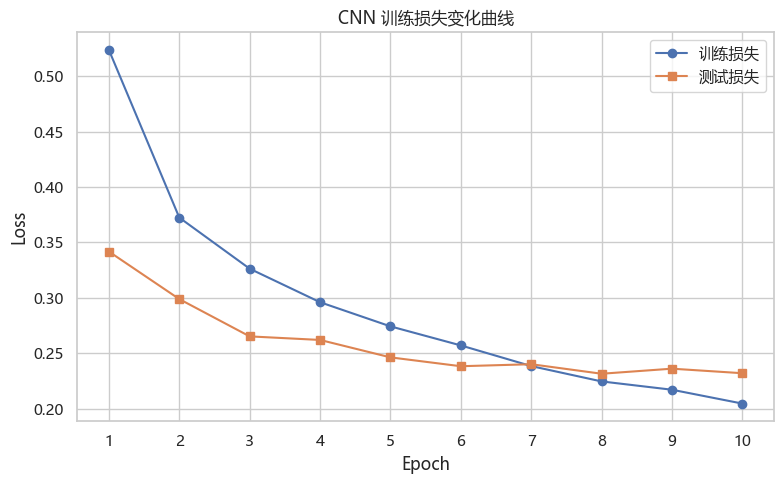

图像已保存：exp4_accuracy_curve.png


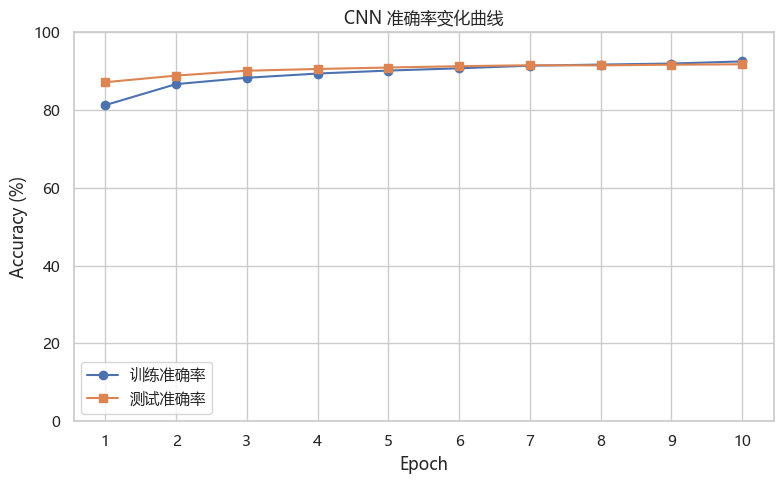

图像已保存：exp4_epoch_time.png


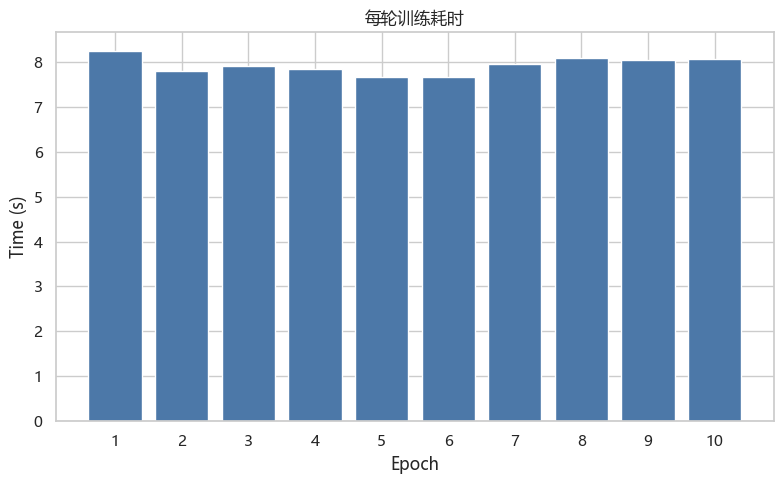

In [8]:
def plot_training_loss(history_df: pd.DataFrame) -> None:
    """
    绘制训练损失和测试损失曲线。
    """
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="训练损失")
    plt.plot(history_df["epoch"], history_df["test_loss"], marker="s", label="测试损失")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("CNN 训练损失变化曲线")
    plt.xticks(history_df["epoch"])
    plt.legend()
    plt.tight_layout()
    save_plot("exp4_training_loss.png")


def plot_accuracy_curve(history_df: pd.DataFrame) -> None:
    """
    绘制训练准确率和测试准确率曲线。
    """
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_accuracy"] * 100, marker="o", label="训练准确率")
    plt.plot(history_df["epoch"], history_df["test_accuracy"] * 100, marker="s", label="测试准确率")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("CNN 准确率变化曲线")
    plt.xticks(history_df["epoch"])
    plt.ylim(0, 100)
    plt.legend()
    plt.tight_layout()
    save_plot("exp4_accuracy_curve.png")


def plot_epoch_time(history_df: pd.DataFrame) -> None:
    """
    绘制每轮训练和测试总耗时。
    """
    plt.figure(figsize=(8, 5))
    plt.bar(history_df["epoch"], history_df["seconds"], color="#4C78A8")
    plt.xlabel("Epoch")
    plt.ylabel("Time (s)")
    plt.title("每轮训练耗时")
    plt.xticks(history_df["epoch"])
    plt.tight_layout()
    save_plot("exp4_epoch_time.png")


plot_training_loss(history_df)
plot_accuracy_curve(history_df)
plot_epoch_time(history_df)


## 第 8 步：在测试集上做最终评估

这一部分会计算最终测试集准确率，并整理后续画图需要的预测结果。

除了整体准确率，后面还会看：

- 混淆矩阵
- 每个类别的准确率
- 最容易混淆的类别对


In [9]:
def collect_predictions(
    model: nn.Module,
    dataloader: DataLoader,
    device: torch.device,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    收集测试集真实标签和预测标签。
    """
    model.eval()
    all_labels: List[int] = []
    all_preds: List[int] = []

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device, non_blocking=True)
            logits = model(images)
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds.tolist())
            all_labels.extend(labels.numpy().tolist())

    return np.array(all_labels), np.array(all_preds)


def make_confusion_matrix(labels: np.ndarray, preds: np.ndarray, num_classes: int = 10) -> np.ndarray:
    """
    计算混淆矩阵，行表示真实类别，列表示预测类别。
    """
    matrix = np.zeros((num_classes, num_classes), dtype=int)
    for true_label, pred_label in zip(labels, preds):
        matrix[int(true_label), int(pred_label)] += 1
    return matrix


def print_per_class_accuracy(matrix: np.ndarray) -> None:
    """
    在终端输出每个类别的准确率，方便实验报告截图和文字分析。
    """
    row_sums = matrix.sum(axis=1)
    class_acc = np.divide(np.diag(matrix), row_sums, out=np.zeros_like(row_sums, dtype=float), where=row_sums != 0)

    print("\n各类别测试准确率：")
    for class_name, acc in zip(CLASS_NAMES, class_acc):
        print(f"{class_name:12s}: {acc * 100:.2f}%")


def print_top_confusions(matrix: np.ndarray, top_k: int = 5) -> None:
    """
    输出最容易混淆的类别对，便于写结果分析。
    """
    confusion_pairs = []
    for true_idx in range(matrix.shape[0]):
        for pred_idx in range(matrix.shape[1]):
            if true_idx != pred_idx:
                confusion_pairs.append((matrix[true_idx, pred_idx], true_idx, pred_idx))

    confusion_pairs.sort(reverse=True)
    print(f"\n混淆最多的前 {top_k} 个类别对：")
    for count, true_idx, pred_idx in confusion_pairs[:top_k]:
        print(f"真实 {CLASS_NAMES[true_idx]:12s} -> 预测 {CLASS_NAMES[pred_idx]:12s}: {count} 张")


final_test_loss, final_test_acc = run_one_epoch(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    optimizer=None,
    device=device,
)

print("最终测试集结果：")
print(f"test_loss={final_test_loss:.4f}")
print(f"test_accuracy={final_test_acc:.4f}")
print(f"Final Test Accuracy: {final_test_acc * 100:.2f}%")

labels, preds = collect_predictions(model, test_loader, device)
confusion_matrix = make_confusion_matrix(labels, preds, num_classes=len(CLASS_NAMES))

print_per_class_accuracy(confusion_matrix)
print_top_confusions(confusion_matrix)

confusion_df = pd.DataFrame(confusion_matrix, index=CLASS_NAMES, columns=CLASS_NAMES)
display(confusion_df)


最终测试集结果：
test_loss=0.2319
test_accuracy=0.9178
Final Test Accuracy: 91.78%

各类别测试准确率：
T-shirt/top : 90.00%
Trouser     : 98.50%
Pullover    : 86.90%
Dress       : 90.80%
Coat        : 90.00%
Sandal      : 98.70%
Shirt       : 70.50%
Sneaker     : 98.20%
Bag         : 98.60%
Ankle boot  : 95.60%

混淆最多的前 5 个类别对：
真实 Shirt        -> 预测 T-shirt/top : 131 张
真实 Shirt        -> 预测 Coat        : 74 张
真实 T-shirt/top  -> 预测 Shirt       : 64 张
真实 Shirt        -> 预测 Pullover    : 54 张
真实 Pullover     -> 预测 Coat        : 53 张


,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot
T-shirt/top,900,0,19,11,2,1,64,0,3,0
Trouser,2,985,1,8,0,0,2,0,2,0
Pullover,19,1,869,7,53,0,50,0,1,0
Dress,21,4,11,908,25,0,30,0,1,0
Coat,1,0,37,23,900,0,38,0,1,0
Sandal,0,0,0,0,0,987,0,8,0,5
Shirt,131,2,54,26,74,0,705,0,8,0
Sneaker,0,0,0,0,0,7,0,982,0,11
Bag,3,1,1,3,1,1,2,2,986,0
Ankle boot,0,0,0,0,0,5,0,38,1,956


## 第 8.1 步：绘制混淆矩阵和每类准确率

这里会保存三张图：

- `exp4_confusion_matrix.png`：普通混淆矩阵
- `exp4_confusion_matrix_normalized.png`：百分比形式的混淆矩阵
- `exp4_per_class_accuracy.png`：每个类别的测试准确率


图像已保存：exp4_confusion_matrix.png


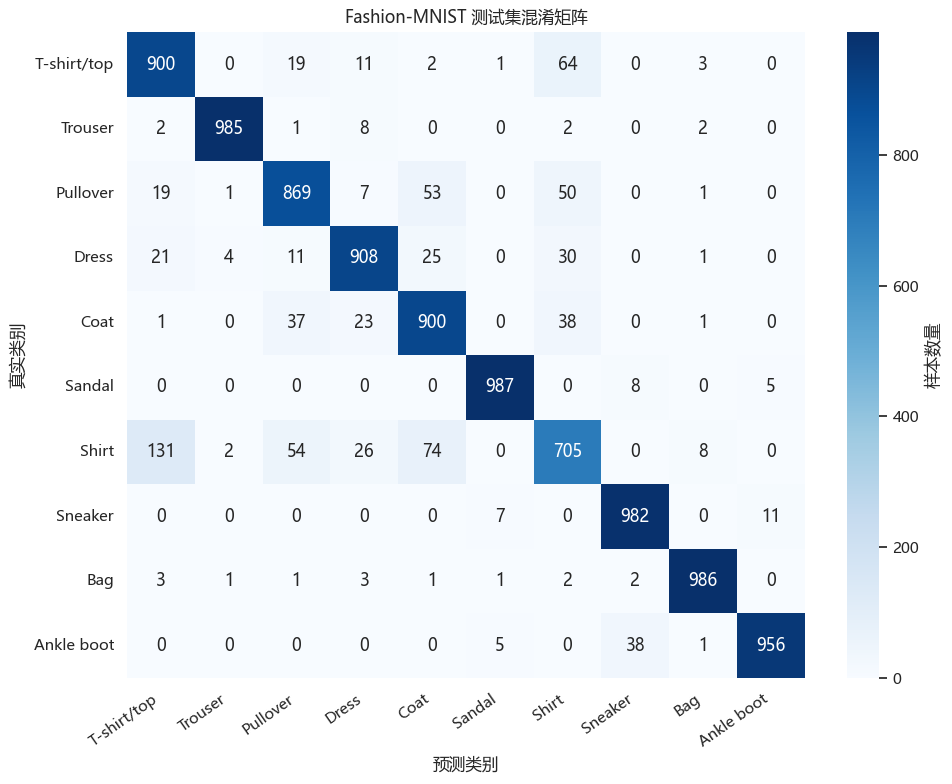

图像已保存：exp4_confusion_matrix_normalized.png


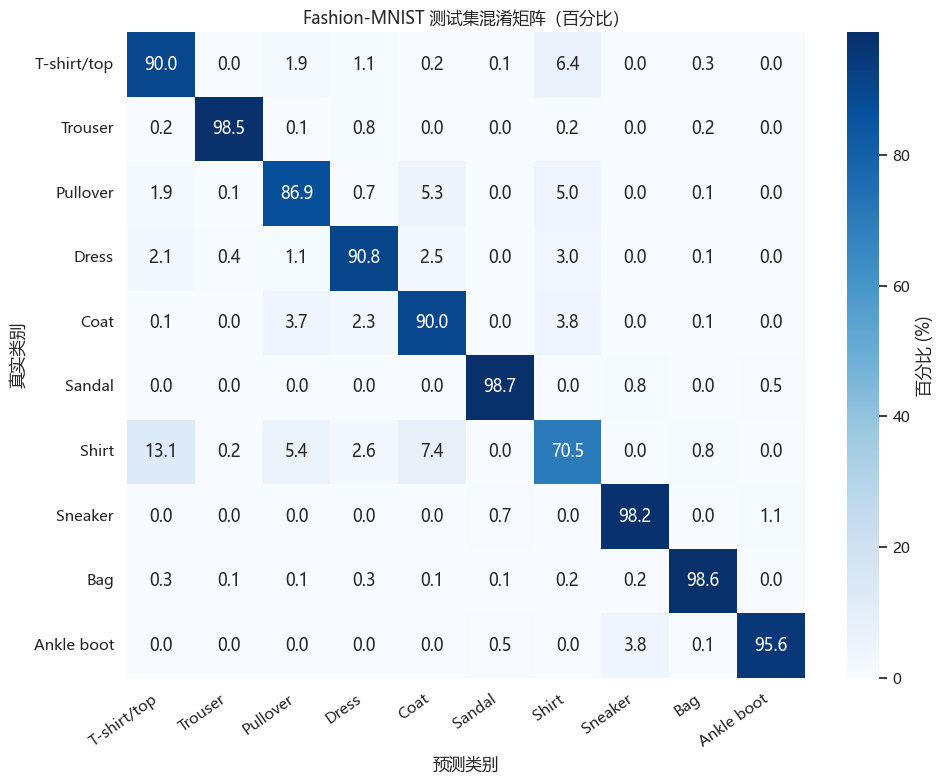

图像已保存：exp4_per_class_accuracy.png


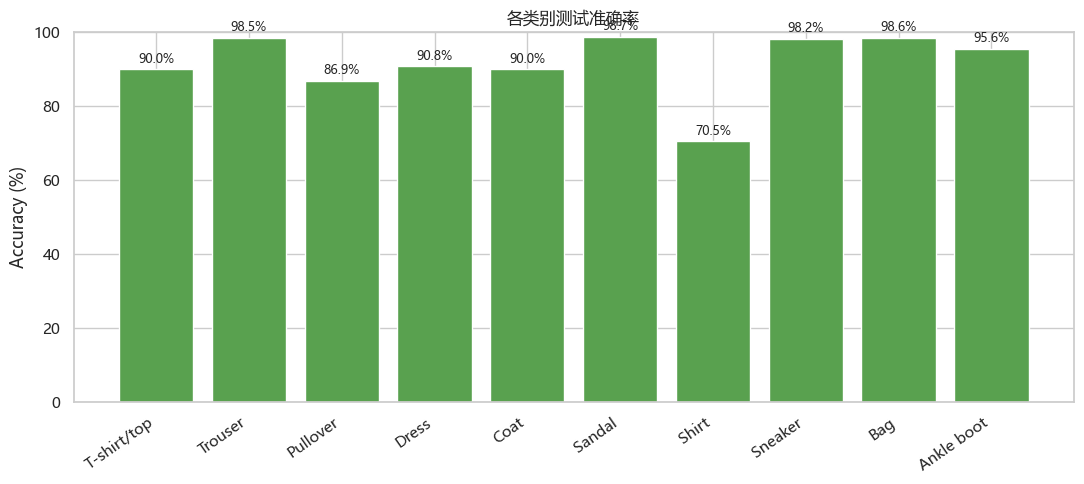

In [10]:
def plot_confusion_matrix(matrix: np.ndarray, filename: str, normalized: bool = False) -> None:
    """
    绘制混淆矩阵，观察哪些类别容易被混淆。
    """
    if normalized:
        row_sums = matrix.sum(axis=1, keepdims=True)
        data = np.divide(matrix, row_sums, out=np.zeros_like(matrix, dtype=float), where=row_sums != 0) * 100
        fmt = ".1f"
        title = "Fashion-MNIST 测试集混淆矩阵（百分比）"
        cbar_label = "百分比 (%)"
    else:
        data = matrix
        fmt = "d"
        title = "Fashion-MNIST 测试集混淆矩阵"
        cbar_label = "样本数量"

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        data,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        cbar_kws={"label": cbar_label},
    )
    plt.xlabel("预测类别")
    plt.ylabel("真实类别")
    plt.title(title)
    plt.xticks(rotation=35, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    save_plot(filename)


def plot_per_class_accuracy(matrix: np.ndarray) -> None:
    """
    绘制每个类别的测试准确率。
    """
    row_sums = matrix.sum(axis=1)
    class_acc = np.divide(np.diag(matrix), row_sums, out=np.zeros_like(row_sums, dtype=float), where=row_sums != 0)

    plt.figure(figsize=(11, 5))
    bars = plt.bar(CLASS_NAMES, class_acc * 100, color="#59A14F")
    plt.ylabel("Accuracy (%)")
    plt.title("各类别测试准确率")
    plt.xticks(rotation=35, ha="right")
    plt.ylim(0, 100)

    for bar, acc in zip(bars, class_acc):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{acc * 100:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    save_plot("exp4_per_class_accuracy.png")


plot_confusion_matrix(confusion_matrix, filename="exp4_confusion_matrix.png", normalized=False)
plot_confusion_matrix(confusion_matrix, filename="exp4_confusion_matrix_normalized.png", normalized=True)
plot_per_class_accuracy(confusion_matrix)


## 第 8.2 步：随机展示 8 张测试图片的预测结果

标题中会显示真实类别和预测类别：

- 绿色：预测正确
- 红色：预测错误

保存图片：`exp4_prediction_examples.png`


图像已保存：exp4_prediction_examples.png


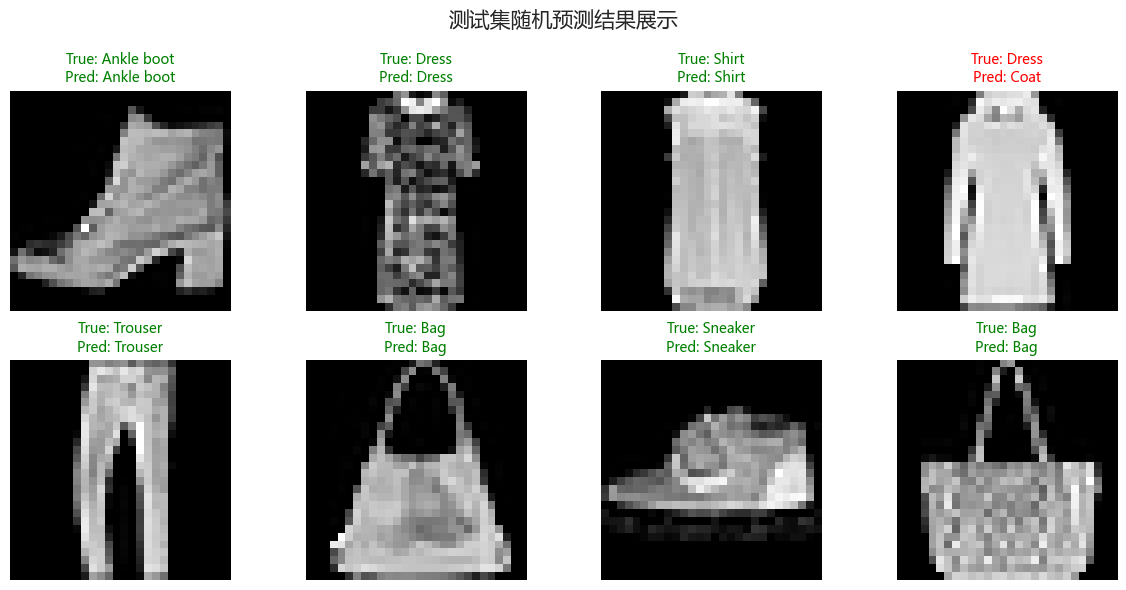

In [11]:
def plot_prediction_examples(
    model: nn.Module,
    dataset: datasets.FashionMNIST,
    device: torch.device,
) -> None:
    """
    随机展示 8 张测试图像，并标出真实标签和预测标签。
    """
    rng = random.Random(RANDOM_SEED + 7)
    indices = rng.sample(range(len(dataset)), 8)

    images = torch.stack([dataset[idx][0] for idx in indices])
    labels_tensor = torch.tensor([dataset[idx][1] for idx in indices])

    model.eval()
    with torch.no_grad():
        logits = model(images.to(device))
        preds_tensor = logits.argmax(dim=1).cpu()

    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for ax, image, true_label, pred_label in zip(axes.flat, images, labels_tensor, preds_tensor):
        image = denormalize_image(image).squeeze(0)
        ax.imshow(image, cmap="gray")
        color = "green" if int(true_label) == int(pred_label) else "red"
        ax.set_title(
            f"True: {CLASS_NAMES[int(true_label)]}\nPred: {CLASS_NAMES[int(pred_label)]}",
            color=color,
            fontsize=10,
        )
        ax.axis("off")

    plt.suptitle("测试集随机预测结果展示", fontsize=15)
    plt.tight_layout()
    save_plot("exp4_prediction_examples.png")


plot_prediction_examples(model, test_dataset, device)


## 第 9 步：超参数影响分析

这里比较不同卷积通道数对准确率的影响：

- `small 16-32`
- `base 32-64`
- `large 64-128`

为了节省运行时间，这一部分默认每组只训练 `5` 轮，并从训练集中抽取 `15000` 张图片做对比训练。  
如果电脑运行较慢，可以跳过这个单元格，或者把第 1 步中的 `RUN_HYPERPARAMETER_COMPARISON` 改成 `False`。

保存图片：`exp4_hyperparameter_comparison.png`


========== 超参数对比：不同卷积通道数 ==========
说明：为节省时间，超参数对比每组训练 5 epochs，训练子集样本数为 15000。
small 16-32 | Epoch 01/5 | train_loss=0.6973 | train_acc=0.7500 | test_acc=0.8306 | time=2.73s
small 16-32 | Epoch 02/5 | train_loss=0.4576 | train_acc=0.8345 | test_acc=0.8608 | time=2.76s
small 16-32 | Epoch 03/5 | train_loss=0.3988 | train_acc=0.8569 | test_acc=0.8705 | time=2.78s
small 16-32 | Epoch 04/5 | train_loss=0.3514 | train_acc=0.8707 | test_acc=0.8779 | time=2.79s
small 16-32 | Epoch 05/5 | train_loss=0.3255 | train_acc=0.8810 | test_acc=0.8792 | time=2.75s
base 32-64 | Epoch 01/5 | train_loss=0.7237 | train_acc=0.7436 | test_acc=0.8194 | time=2.77s
base 32-64 | Epoch 02/5 | train_loss=0.4858 | train_acc=0.8245 | test_acc=0.8587 | time=2.74s
base 32-64 | Epoch 03/5 | train_loss=0.4209 | train_acc=0.8457 | test_acc=0.8683 | time=2.78s
base 32-64 | Epoch 04/5 | train_loss=0.3696 | train_acc=0.8630 | test_acc=0.8707 | time=2.79s
base 32-64 | Epoch 05/5 | train_loss=0.3509 | train_acc=0.8692 | test

,name,channels,train_accuracy,test_accuracy,seconds
0,small 16-32,"(16, 32)",0.881000,0.8792,13.809641
1,base 32-64,"(32, 64)",0.869200,0.8744,13.888274
2,large 64-128,"(64, 128)",0.864733,0.8831,13.939356


图像已保存：exp4_hyperparameter_comparison.png


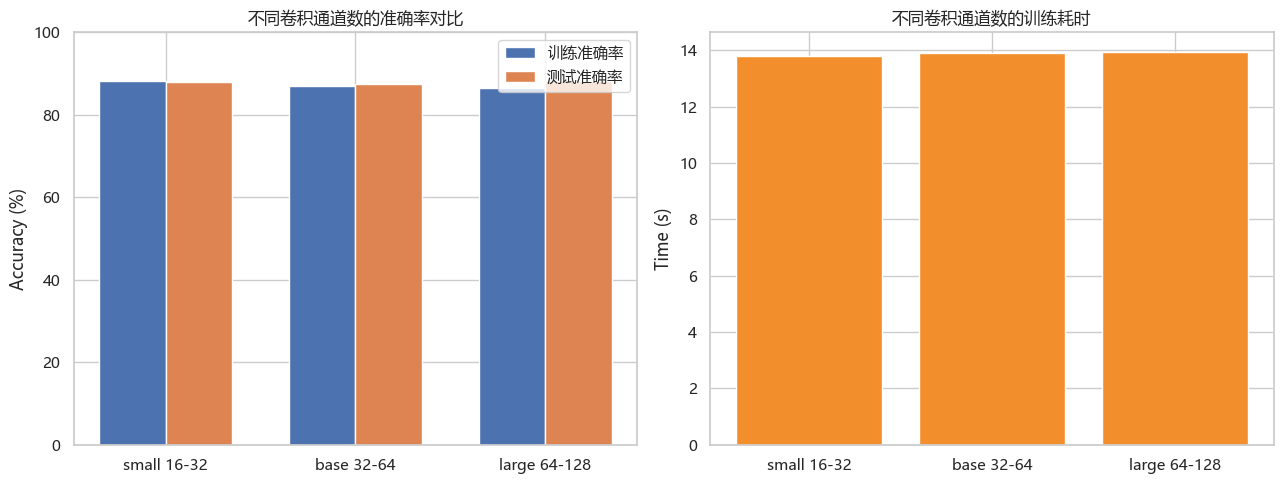

In [12]:
def make_subset(dataset: Dataset, limit: Optional[int], seed: int) -> Dataset:
    """
    从数据集中固定随机抽取一部分样本，用于较快完成超参数对比。
    """
    if limit is None or limit >= len(dataset):
        return dataset
    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(len(dataset), generator=generator)[:limit].tolist()
    return Subset(dataset, indices)


def plot_hyperparameter_comparison(results_df: pd.DataFrame) -> None:
    """
    绘制不同卷积通道数组合的准确率和耗时对比。
    """
    names = results_df["name"].tolist()
    train_acc = results_df["train_accuracy"].to_numpy() * 100
    test_acc = results_df["test_accuracy"].to_numpy() * 100
    seconds = results_df["seconds"].to_numpy()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    x = np.arange(len(names))
    width = 0.35
    axes[0].bar(x - width / 2, train_acc, width=width, label="训练准确率")
    axes[0].bar(x + width / 2, test_acc, width=width, label="测试准确率")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(names)
    axes[0].set_ylabel("Accuracy (%)")
    axes[0].set_title("不同卷积通道数的准确率对比")
    axes[0].set_ylim(0, 100)
    axes[0].legend()

    axes[1].bar(names, seconds, color="#F28E2B")
    axes[1].set_ylabel("Time (s)")
    axes[1].set_title("不同卷积通道数的训练耗时")

    plt.tight_layout()
    save_plot("exp4_hyperparameter_comparison.png")


def run_hyperparameter_comparison(
    train_dataset: datasets.FashionMNIST,
    test_loader: DataLoader,
    device: torch.device,
) -> pd.DataFrame:
    """
    比较不同卷积核数量对分类效果的影响。
    """
    print("========== 超参数对比：不同卷积通道数 ==========")
    print(
        f"说明：为节省时间，超参数对比每组训练 {HYPERPARAM_EPOCHS} epochs，"
        f"训练子集样本数为 {min(HYPERPARAM_TRAIN_LIMIT, len(train_dataset))}。"
    )

    train_subset = make_subset(train_dataset, HYPERPARAM_TRAIN_LIMIT, RANDOM_SEED + 99)
    small_train_loader = DataLoader(
        train_subset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    experiments = [
        ("small 16-32", (16, 32)),
        ("base 32-64", (32, 64)),
        ("large 64-128", (64, 128)),
    ]

    criterion = nn.CrossEntropyLoss()
    results = []

    for name, channels in experiments:
        set_seed(RANDOM_SEED)
        compare_model = FashionCNN(channels=channels).to(device)
        compare_optimizer = torch.optim.Adam(compare_model.parameters(), lr=LEARNING_RATE)

        start_time = time.time()
        compare_history = train_model(
            model=compare_model,
            train_loader=small_train_loader,
            test_loader=test_loader,
            criterion=criterion,
            optimizer=compare_optimizer,
            device=device,
            num_epochs=HYPERPARAM_EPOCHS,
            log_prefix=f"{name} | ",
        )
        total_seconds = time.time() - start_time
        final_row = compare_history.iloc[-1]

        results.append(
            {
                "name": name,
                "channels": str(channels),
                "train_accuracy": final_row["train_accuracy"],
                "test_accuracy": final_row["test_accuracy"],
                "seconds": total_seconds,
            }
        )

    results_df = pd.DataFrame(results)
    print("\n超参数对比结果汇总：")
    display(results_df)
    plot_hyperparameter_comparison(results_df)
    return results_df


if RUN_HYPERPARAMETER_COMPARISON:
    hyperparameter_results_df = run_hyperparameter_comparison(train_dataset, test_loader, device)
else:
    print("已跳过超参数对比。若需要生成图像，请把 RUN_HYPERPARAMETER_COMPARISON 改为 True 后重新运行本单元格。")


## 实验小结

到这里，实验4的主要代码已经完成。

写实验报告时可以从下面几个角度展开：

- CNN 通过局部感受野提取图像局部边缘、纹理和形状信息。
- 卷积核在整张图像上滑动，体现了权值共享，可以减少参数量。
- 池化层完成下采样，降低特征图尺寸，也能增强一定的平移鲁棒性。
- 两层卷积逐步完成层次化特征提取：浅层偏向局部边缘，深层偏向更完整的服饰形状。
- 相比实验三的 MLP，CNN 没有一开始就把图片展平，因此更好地保留了图像的二维空间结构。
- 整个模型从输入图像到输出类别端到端学习，训练流程更适合图像分类任务。
